<a href="https://colab.research.google.com/github/panaddatappoomee/food-selection-data-science/blob/main/Project_Library_Group2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ขั้นตอนที่ 1 เตรียมข้อมูล
ข้อมูลหนังสือ : กำหนดรหัสหนังสือ(D000-001ถึงD900-015), หมวดหมู่(D000-D900), ชื่อผู้แต่ง, ชื่อหนังสือ

ข้อมูลสมาชิก : กำหนดรหัสสมาชิก(PS0001-PT0050), หมวดหมู่สมาชิก(นักศึกษา,อาจารย์)

##ข้อมูลหลักที่ต้องเก็บ: หนังสือ, สมาชิก, การยืมคืน

##คุณสมบัติ
หนังสือ: รหัสหนังสือ, ชื่อเรื่อง, ชื่อผู้แต่ง, หมวดหมู่, สถานะ(ว่าง/ถูกยืม)

สมาชิก: รหัสสมาชิก, ชื่อ, ประเภทสมาชิก(นักศึกษา/อาจารย์), จำนวนวันที่ยืมได้

การยืม: รหัสการยืม ( L0001-L00350 ) , หนังสือที่ยืม, สมาชิกที่ยืม, วันที่ยืม, กำหนดคืน, วันที่คืนจริง

##หน้าที่

หนังสือ: ยืม, คืน

การยืม: คำนวณค่าปรับ, บันทึกการคืน

##การคำนวณค่าปรับ

ระยะเวลาการยืมต่างกัน นักศึกษายืมได้ 14 วัน อาจารย์ยืมได้ 30 วัน


ค่าปรับตามจำนวนวันที่คืนช้า 5บาทต่อวัน

#หมวดหมู่หนังสือ
​D000 คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ (Computer science, Information & General works)

​D100 ปรัชญา และจิตวิทยา (Philosophy & Psychology)

​D200 ศาสนา (Religion)

​D300 สังคมศาสตร์ (Social sciences)

​D400 ภาษาศาสตร์ (Language)

​D500 วิทยาศาสตร์ (Science)

​D600 เทคโนโลยี และวิทยาศาสตร์ประยุกต์ (Technology)

D​700 ศิลปะ และการบันเทิง (Arts & Recreation)

​D800 วรรณคดี และวรรณกรรม (Literature)

​D900 ประวัติศาสตร์ และภูมิศาสตร์ (History & Geography)

In [101]:
#นำเข้าฟอนต์กราฟ
!pip install openpyxl
import pandas as pd

In [102]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. ติดตั้งฟอนต์ภาษาไทยลงในระบบ Colab
!apt-get -y install fonts-thai-tlwg > /dev/null 2>&1

# 2. โหลดไฟล์ฟอนต์เข้า Memory และตั้งค่า font_prop
font_path = "/usr/share/fonts/truetype/tlwg/Laksaman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 3. ตั้งค่า Default ให้ Matplotlib รู้จักฟอนต์และรองรับเครื่องหมายลบ
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ขั้นตอนที่ 2 — ออกแบบ Class

In [103]:
#Import และสร้าง Class
import random
from datetime import datetime, timedelta


class Book:
    def __init__(self, book_id, title, author, category_code, category_name, status="ว่าง"):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.category_code = category_code
        self.category_name = category_name
        self.is_available = (status == "ว่าง")

    def borrow(self):
        """เปลี่ยนสถานะเป็นถูกยืม"""
        self.is_available = False

    def return_book(self):
        """เปลี่ยนสถานะกลับเป็นว่าง"""
        self.is_available = True


class Member:
    def __init__(self, member_id, name, member_type, loan_period_days):
        self.member_id = member_id
        self.name = name
        self.member_type = member_type
        self.loan_period_days = loan_period_days


class BookLoan:
    FINE_PER_DAY = 5

    def __init__(self, loan_id, book, member, borrow_date):
        self.loan_id = loan_id
        self.book = book
        self.member = member
        self.borrow_date = borrow_date

        self.due_date = borrow_date + timedelta(
            days=member.loan_period_days
        )

        self.return_date = None

    def calculate_late_fee(self):
        """คำนวณค่าปรับถ้าคืนช้ากว่ากำหนด"""

        if self.return_date is not None and self.return_date > self.due_date:
            late_days = (self.return_date - self.due_date).days
            return late_days * self.FINE_PER_DAY

        return 0

    def mark_returned(self, return_date):
        """บันทึกว่าคืนหนังสือแล้ว"""

        self.return_date = return_date
        self.book.return_book()

# ขั้นตอนที่ 3 - เขียนฟังก์ชันช่วยงาน (Helper Function)

In [104]:
import pandas as pd

# ฟังชันก์ load() โหลดข้อมูลจากไฟล์ books.csv
def load_books(csv_path):
    """โหลดหนังสือจากไฟล์ CSV แล้วสร้างเป็น Book object"""

    df = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/books.csv")

    return [
        Book(
            row.book_id,
            row.title,
            row.author,
            row.category_code,
            row.category_name,
            row.status
        )
        for row in df.itertuples(index=False)
    ]

# ฟังก์ชัน load()โหลดข้อมูลจากไฟล์ members.csv
def load_members(csv_path):
    """โหลดสมาชิกจากไฟล์ CSV แล้วสร้างเป็น Member object"""

    df = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/members.csv")

    return [
        Member(
            row.member_id,
            row.name,
            row.member_type,
            row.loan_period_days
        )
        for row in df.itertuples(index=False)
    ]

# ฟังก์ชัน สุ่มวันที่ยืม-คืน
def random_borrow_date(start_date, days_range=300):
    """สุ่มวันที่ยืม"""

    offset = random.randint(0, days_range)

    return start_date + timedelta(days=offset)


def decide_return_outcome(
    never_return_probability=0.20,
    late_probability=0.25
):
    """สุ่มผลการคืนหนังสือ"""

    r = random.random()

    if r < never_return_probability:
        return "not_returned"

    elif r < never_return_probability + late_probability:
        return "late"

    else:
        return "on_time"


def calculate_return_date(due_date, outcome):
    """คำนวณวันที่คืนตามผลการสุ่ม"""

    if outcome == "not_returned":
        return None

    elif outcome == "late":
        return due_date + timedelta(days=random.randint(1, 10))

    else:
        return due_date - timedelta(days=random.randint(0, 5))

## ขั้นตอนที่ 3.1 — ทดสอบฟังก์ชันทีละตัว ก่อนเอาไปประกอบเป็นกระบวนการ

In [105]:
# เรียก load_books() และ load_members() -> โหลดข้อมูลจาก CSV แล้วแปลงแต่ละแถวเป็น object
test_books = load_books("books.csv")
test_members = load_members("members.csv")

print("จำนวนหนังสือที่โหลดได้:", len(test_books))
print("จำนวนสมาชิกที่โหลดได้:", len(test_members))

print("\nตัวอย่างหนังสือเล่มแรก:")
print("  รหัส:", test_books[0].book_id, "| ชื่อ:", test_books[0].title, "| สถานะว่าง:", test_books[0].is_available)

print("\nตัวอย่างสมาชิกคนแรก:")
print("  รหัส:", test_members[0].member_id, "| ชื่อ:", test_members[0].name,
      "| ประเภท:", test_members[0].member_type, "| ยืมได้:", test_members[0].loan_period_days, "วัน")

จำนวนหนังสือที่โหลดได้: 150
จำนวนสมาชิกที่โหลดได้: 350

ตัวอย่างหนังสือเล่มแรก:
  รหัส: D000-001 | ชื่อ: พื้นฐานการเขียนโปรแกรมด้วย Python | สถานะว่าง: True

ตัวอย่างสมาชิกคนแรก:
  รหัส: PS0001 | ชื่อ: รติ | ประเภท: นักศึกษา | ยืมได้: 14 วัน


In [106]:
# เรียก random_borrow_date() ซ้ำหลายครั้งด้วย start_date เดียวกัน -> ทุกครั้งควรได้วันที่สุ่มไม่ซ้ำแบบ
demo_start = datetime(2025, 1, 1)

for _ in range(3):
    print("วันที่ยืมที่สุ่มได้:", random_borrow_date(demo_start))


วันที่ยืมที่สุ่มได้: 2025-02-15 00:00:00
วันที่ยืมที่สุ่มได้: 2025-09-21 00:00:00
วันที่ยืมที่สุ่มได้: 2025-06-03 00:00:00


In [107]:
# เรียก decide_return_outcome() 10 ครั้ง เพื่อดูสัดส่วนผลลัพธ์ 3 แบบ (not_returned / late / on_time)
outcomes = [decide_return_outcome() for _ in range(10)]
print("ผลลัพธ์ที่สุ่มได้ 10 ครั้ง:", outcomes)


ผลลัพธ์ที่สุ่มได้ 10 ครั้ง: ['late', 'on_time', 'late', 'on_time', 'on_time', 'on_time', 'on_time', 'late', 'not_returned', 'on_time']


In [108]:
# ฟังก์ชัน calculate_return_date() รับ due_date + outcome -> คืนค่าเป็นวันที่คืนจริง (หรือ None ถ้าไม่คืน)
demo_due = demo_start + timedelta(days=14)

print("กำหนดคืน (due_date):", demo_due.strftime("%Y-%m-%d"))
print("ถ้าผลคือ 'not_returned':", calculate_return_date(demo_due, "not_returned"))
print("ถ้าผลคือ 'late'        :", calculate_return_date(demo_due, "late"))
print("ถ้าผลคือ 'on_time'     :", calculate_return_date(demo_due, "on_time"))

กำหนดคืน (due_date): 2025-01-15
ถ้าผลคือ 'not_returned': None
ถ้าผลคือ 'late'        : 2025-01-21 00:00:00
ถ้าผลคือ 'on_time'     : 2025-01-14 00:00:00


#ขั้นตอนที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [109]:
import pandas as pd
from datetime import datetime, timedelta

books = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/books.csv", encoding="utf-8-sig").set_index("book_id")
members = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/members.csv", encoding="utf-8-sig").set_index("member_id")

In [110]:
# 3.จำลองการยืมหนังสือ 350 รายการ
random.seed(1)

books = load_books("books.csv")
members = load_members("members.csv")

loans = []

start_date = datetime(2025, 1, 1)


for i in range(1, 351):

    available_books = [
        b for b in books
        if b.is_available
    ]

    if not available_books:

        available_books = books

        for b in available_books:
            b.return_book()

    book = random.choice(available_books)

    member = random.choice(members)

    borrow_date = random_borrow_date(start_date)

    loan_id = f"L{i:04d}"

    loan = BookLoan(
        loan_id,
        book,
        member,
        borrow_date
    )

    book.borrow()

    outcome = decide_return_outcome()

    return_date = calculate_return_date(
        loan.due_date,
        outcome
    )

    if return_date is not None:
        loan.mark_returned(return_date)

    loans.append(loan)


print(f"จำลองการยืมเสร็จแล้วทั้งหมด {len(loans)} รายการ")

จำลองการยืมเสร็จแล้วทั้งหมด 350 รายการ


## ขั้นตอนที่ 4.1 — จำลอง "สมาชิก 1 คนมายืมหนังสือ" แบบ step-by-step

In [111]:
import time

def simulate_one_loan(loan_id, books, members, start_date, pause=0.0):
    """จำลองขั้นตอนทั้งหมดตอนสมาชิก 1 คนมายืมหนังสือ 1 เล่ม แล้วคืนค่า object BookLoan ที่สร้างเสร็จแล้ว
    """

    print("=" * 60)

    available_books = [b for b in books if b.is_available]
    if not available_books:
        available_books = books
        for b in available_books:
            b.return_book()

    book = random.choice(available_books)
    member = random.choice(members)

    print(f"📚 รายการยืม #{loan_id}: สมาชิก '{member.name}' ({member.member_type}) รหัส {member.member_id} "
      f"เดินมาที่เคาน์เตอร์ ต้องการยืมหนังสือ")
    time.sleep(pause)

    print(f"🔎 พนักงานค้นหาหนังสือว่าง เจอ: '{book.title}' (รหัส {book.book_id}, หมวด {book.category_name})")
    time.sleep(pause)

    borrow_date = random_borrow_date(start_date)
    loan = BookLoan(loan_id, book, member, borrow_date)
    book.borrow()

    print(f"📝 ระบบบันทึกการยืมเรียบร้อย (สถานะหนังสือว่าง = {book.is_available})")
    print(f"   วันที่ยืม: {borrow_date.strftime('%Y-%m-%d')} | "
          f"กำหนดคืน: {loan.due_date.strftime('%Y-%m-%d')} "
          f"({member.loan_period_days} วัน ตามประเภทสมาชิก '{member.member_type}')")
    time.sleep(pause)



    return_date = calculate_return_date(loan.due_date, outcome)

    if return_date is not None:
        loan.mark_returned(return_date)
        print(f"✅ คืนหนังสือแล้วเมื่อ {return_date.strftime('%Y-%m-%d')} "
              f"(สถานะหนังสือกลับเป็นว่าง = {book.is_available})")
    else:
        print("⏳ ยังไม่คืนหนังสือ (สถานะ: not_returned)")

    late_fee = loan.calculate_late_fee()
    print(f"🧾 สรุปรายการ #{loan_id}: {member.name} ยืม '{book.title}' | ค่าปรับ: {late_fee} บาท")

    return loan


# เรียกใช้ทดสอบ 1 ครั้ง ด้วยข้อมูลชุดแยกต่างหาก (ไม่กระทบข้อมูลที่จะใช้จำลอง 350 รายการจริงในขั้นตอนที่ 4 ด้านบน)
demo_books = load_books("books.csv")
demo_members = load_members("members.csv")

demo_loan = simulate_one_loan("DEMO-001", demo_books, demo_members, datetime(2025, 1, 1), pause=0.5)

📚 รายการยืม #DEMO-001: สมาชิก 'ชูการ์' (นักศึกษา) รหัส PS0252 เดินมาที่เคาน์เตอร์ ต้องการยืมหนังสือ
🔎 พนักงานค้นหาหนังสือว่าง เจอ: 'วิทยาศาสตร์สิ่งแวดล้อม' (รหัส D500-015, หมวด วิทยาศาสตร์)
📝 ระบบบันทึกการยืมเรียบร้อย (สถานะหนังสือว่าง = False)
   วันที่ยืม: 2025-10-02 | กำหนดคืน: 2025-10-16 (14 วัน ตามประเภทสมาชิก 'นักศึกษา')
✅ คืนหนังสือแล้วเมื่อ 2025-10-21 (สถานะหนังสือกลับเป็นว่าง = True)
🧾 สรุปรายการ #DEMO-001: ชูการ์ ยืม 'วิทยาศาสตร์สิ่งแวดล้อม' | ค่าปรับ: 25 บาท


# ขั้นตอนที่ 5 — แปลง Object เป็นตาราง แล้วบันทึกเป็น CSV

In [112]:
# 5.แปลงข้อมูลเป็น DataFrame และบันทึก CSV
records = [
    {
        "loan_id": loan.loan_id,
         "member_id": loan.member.member_id,
        "member_name": loan.member.name,
        "book_id": loan.book.book_id,
        "book_title": loan.book.title,
        "borrow_date": loan.borrow_date.strftime("%Y-%m-%d"),
        "due_date": loan.due_date.strftime("%Y-%m-%d"),
        "return_date": (
            loan.return_date.strftime("%Y-%m-%d")
            if loan.return_date
            else None
        ),
        "late_fee": loan.calculate_late_fee(),
        "status": "คืนแล้ว" if loan.return_date else "ค้างส่ง",
    }

    for loan in loans
]


df_loans = pd.DataFrame(records)

df_loans.to_csv(
    "loans.csv",
    index=False
)

print("บันทึกไฟล์ CSV เสร็จ ขนาด:", df_loans.shape)

df_loans.head()

บันทึกไฟล์ CSV เสร็จ ขนาด: (350, 10)


,loan_id,member_id,member_name,book_id,book_title,borrow_date,due_date,return_date,late_fee,status
0,L0001,PS0292,เนม,D200-005,อิสลามศึกษาเบื้องต้น,2025-02-02,2025-02-16,2025-02-24,40,คืนแล้ว
1,L0002,PS0242,กันต์,D700-011,การแต่งเพลงเบื้องต้น,2025-07-14,2025-07-28,2025-07-28,0,คืนแล้ว
2,L0003,PS0015,ออกัส,D800-005,นวนิยายไทยคลาสสิก,2025-07-19,2025-08-02,2025-08-03,5,คืนแล้ว
3,L0004,PS0137,ฟอร์ด,D700-010,กีฬาและนันทนาการ,2025-04-28,2025-05-12,2025-05-12,0,คืนแล้ว
4,L0005,PS0016,บุ๊ค,D500-007,นิเวศวิทยาและสิ่งแวดล้อม,2025-01-12,2025-01-26,None,0,ค้างส่ง


# ขั้นตอนที่ 6 — สร้างฐานข้อมูล SQLite

In [113]:
# 6.สร้าง SQLite Database
import sqlite3

df_books = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/books.csv", encoding="utf-8-sig")
df_members = pd.read_csv("https://raw.githubusercontent.com/krittiyaT/Project-Group2/main/members.csv", encoding="utf-8-sig")

conn = sqlite3.connect("library.db")

df_books.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

df_members.to_sql(
    "members",
    conn,
    if_exists="replace",
    index=False
)

df_loans.to_sql(
    "loans",
    conn,
    if_exists="replace",
    index=False
)


check = pd.read_sql_query(
    "SELECT * FROM loans LIMIT 5",
    conn
)

print(check)

  loan_id member_id member_name   book_id                book_title  \
0   L0001    PS0292         เนม  D200-005      อิสลามศึกษาเบื้องต้น   
1   L0002    PS0242       กันต์  D700-011      การแต่งเพลงเบื้องต้น   
2   L0003    PS0015       ออกัส  D800-005         นวนิยายไทยคลาสสิก   
3   L0004    PS0137       ฟอร์ด  D700-010          กีฬาและนันทนาการ   
4   L0005    PS0016        บุ๊ค  D500-007  นิเวศวิทยาและสิ่งแวดล้อม   

  borrow_date    due_date return_date  late_fee   status  
0  2025-02-02  2025-02-16  2025-02-24        40  คืนแล้ว  
1  2025-07-14  2025-07-28  2025-07-28         0  คืนแล้ว  
2  2025-07-19  2025-08-02  2025-08-03         5  คืนแล้ว  
3  2025-04-28  2025-05-12  2025-05-12         0  คืนแล้ว  
4  2025-01-12  2025-01-26        None         0  ค้างส่ง  


#ขั้นตอนที่ 7 - วิเคราะห์ข้อมูลด้วย pandas เเละ SQL

##7.1 วิเคราะห์ด้วย pandas

In [114]:
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
).merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

# Q1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby("category_name").agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values("total_loans", ascending=False)
print("Pandas Q1:", category_summary)

Pandas Q1:                            category_name  total_loans  total_late_fee
4                    วรรณคดี และวรรณกรรม           41             310
1            ประวัติศาสตร์ และภูมิศาสตร์           40             460
6                                  ศาสนา           36             150
5                            วิทยาศาสตร์           36             205
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
3                             ภาษาศาสตร์           35             195
7                    ศิลปะ และการบันเทิง           34             310
2                     ปรัชญา และจิตวิทยา           33             155
8                            สังคมศาสตร์           30             215
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90


In [115]:
# Q2 : สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby("member_type").agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values("avg_late_fee", ascending=False)
print("Pandas Q2:", member_type_summary)

Pandas Q2:   member_type  total_loans  avg_late_fee
1     อาจารย์           44     10.113636
0    นักศึกษา          306      5.833333


In [116]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
top_late = df_merged[df_merged["late_fee"]> 0].sort_values(
    ["late_fee", "loan_id"], ascending=[False, True]
)
print("Pandas Q3:", top_late.head())

Pandas Q3:     loan_id member_id member_name   book_id  \
19    L0020    PS0208      เอิร์ธ  D400-002   
72    L0073    PS0058        ท๊อป  D900-001   
182   L0183    PT0029        เล็ก  D300-005   
183   L0184    PT0003        เพ็ญ  D900-003   
212   L0213    PS0190        ภูมิ  D800-003   

                            book_title borrow_date    due_date return_date  \
19   ไวยากรณ์ภาษาอังกฤษเพื่อการสื่อสาร  2025-09-21  2025-10-05  2025-10-15   
72           ประวัติศาสตร์ไทยเบื้องต้น  2025-05-09  2025-05-23  2025-06-02   
182               มานุษยวิทยาเบื้องต้น  2025-05-05  2025-06-04  2025-06-14   
183             ประวัติศาสตร์สงครามโลก  2025-03-31  2025-04-30  2025-05-10   
212                     วรรณกรรมเยาวชน  2025-07-26  2025-08-09  2025-08-19   

     late_fee   status                category_name member_type    name  
19         50  คืนแล้ว                   ภาษาศาสตร์    นักศึกษา  เอิร์ธ  
72         50  คืนแล้ว  ประวัติศาสตร์ และภูมิศาสตร์    นักศึกษา    ท๊อป  
182        50  

In [117]:
# Q4: 5 สมาชิกที่ยืมบ่อยที่สุด
top_members = df_merged.groupby("name").agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values(
    ["total_borrows", "name"], ascending=[False, True]
).head(5)
print("Pandas Q4:", top_members)

Pandas Q4:       name  total_borrows
4    กานต์              4
7      กิต              4
73     ปาง              4
119    มิว              4
148   หมวย              4


In [118]:
# Q5: รายการที่ยังไม่คืน
not_returned = df_merged[df_merged["return_date"].isnull()].sort_values(
    ["due_date", "loan_id"]
)
print("Pandas Q5:", not_returned.head())


Pandas Q5:     loan_id member_id member_name   book_id                     book_title  \
4     L0005    PS0016        บุ๊ค  D500-007       นิเวศวิทยาและสิ่งแวดล้อม   
164   L0165    PS0096        ยุ้ย  D000-015  สารานุกรมความรู้รอบตัว เล่ม 1   
31    L0032    PS0149       ออโต้  D600-004         วิศวกรรมไฟฟ้าเบื้องต้น   
344   L0345    PS0043         พาย  D200-013            เซนและปรัชญาญี่ปุ่น   
279   L0280    PS0016        บุ๊ค  D500-002                     เคมีทั่วไป   

    borrow_date    due_date return_date  late_fee   status  \
4    2025-01-12  2025-01-26        None         0  ค้างส่ง   
164  2025-01-24  2025-02-07        None         0  ค้างส่ง   
31   2025-02-05  2025-02-19        None         0  ค้างส่ง   
344  2025-02-09  2025-02-23        None         0  ค้างส่ง   
279  2025-02-10  2025-02-24        None         0  ค้างส่ง   

                             category_name member_type   name  
4                              วิทยาศาสตร์    นักศึกษา   บุ๊ค  
164  คอมพิวเตอร์ คว

## 7.2 วิเคราะห์ด้วย SQL

In [119]:
# Q1: หมวดไหนถูกยืมมากที่สุด?
q1 = pd.read_sql_query("""
    SELECT b.category_name,
           COUNT(*) AS total_loans,
           SUM(l.late_fee) AS total_late_fee
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    GROUP BY b.category_name
    ORDER BY total_loans DESC;
""", conn)
print("SQL Q1:", q1)

SQL Q1:                            category_name  total_loans  total_late_fee
0                    วรรณคดี และวรรณกรรม           41             310
1            ประวัติศาสตร์ และภูมิศาสตร์           40             460
2                                  ศาสนา           36             150
3                            วิทยาศาสตร์           36             205
4                             ภาษาศาสตร์           35             195
5  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
6                    ศิลปะ และการบันเทิง           34             310
7                     ปรัชญา และจิตวิทยา           33             155
8       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90
9                            สังคมศาสตร์           30             215


In [120]:
# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
q2 = pd.read_sql_query("""
    SELECT m.member_type,
           COUNT(*) AS total_loans,
           AVG(l.late_fee) AS avg_late_fee
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.member_type
    ORDER BY avg_late_fee DESC;
""", conn)
print("SQL Q2:", q2)

SQL Q2:   member_type  total_loans  avg_late_fee
0     อาจารย์           44     10.113636
1    นักศึกษา          306      5.833333


In [121]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
q3 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, member_name, late_fee
    FROM loans
    WHERE late_fee > 0
    ORDER BY late_fee DESC;
""", conn)
print("SQL Q3:", q3.head())

SQL Q3:   loan_id   book_id member_id member_name  late_fee
0   L0020  D400-002    PS0208      เอิร์ธ        50
1   L0073  D900-001    PS0058        ท๊อป        50
2   L0183  D300-005    PT0029        เล็ก        50
3   L0184  D900-003    PT0003        เพ็ญ        50
4   L0213  D800-003    PS0190        ภูมิ        50


In [122]:
# Q4: 5 สมาชิกที่ยืมบ่อยที่สุด
q4 = pd.read_sql_query("""
    SELECT m.name, COUNT(*) AS total_borrows
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.name
    ORDER BY total_borrows DESC, m.name ASC
    LIMIT 5;
""", conn)
print("SQL Q4:", q4)

SQL Q4:     name  total_borrows
0  กานต์              4
1    กิต              4
2    ปาง              4
3    มิว              4
4   หมวย              4


In [123]:
# Q5: รายการที่ยังไม่คืน
q5 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, borrow_date, due_date
    FROM loans
    WHERE return_date IS NULL
    ORDER BY due_date ASC;
""", conn)
print("SQL Q5:", q5.head())

SQL Q5:   loan_id   book_id member_id borrow_date    due_date
0   L0005  D500-007    PS0016  2025-01-12  2025-01-26
1   L0165  D000-015    PS0096  2025-01-24  2025-02-07
2   L0032  D600-004    PS0149  2025-02-05  2025-02-19
3   L0345  D200-013    PS0043  2025-02-09  2025-02-23
4   L0280  D500-002    PS0016  2025-02-10  2025-02-24


# ขั้นตอนที่ 8 — สร้างกราฟและสรุปผล

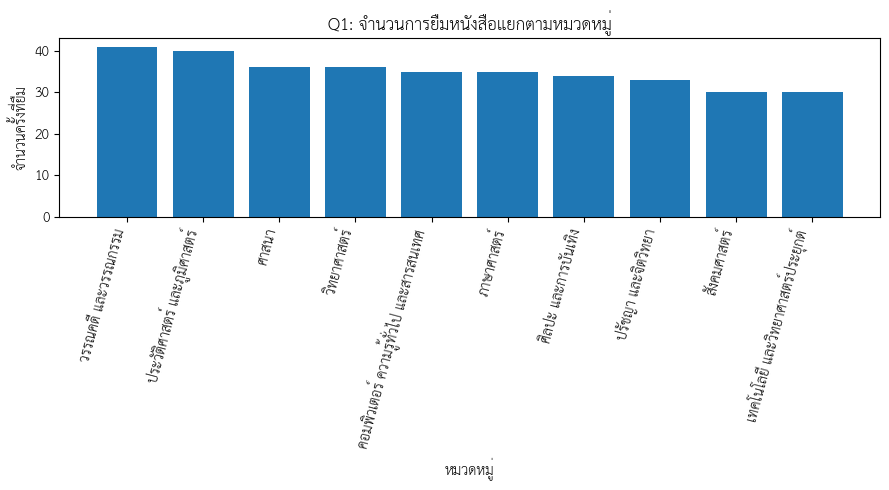

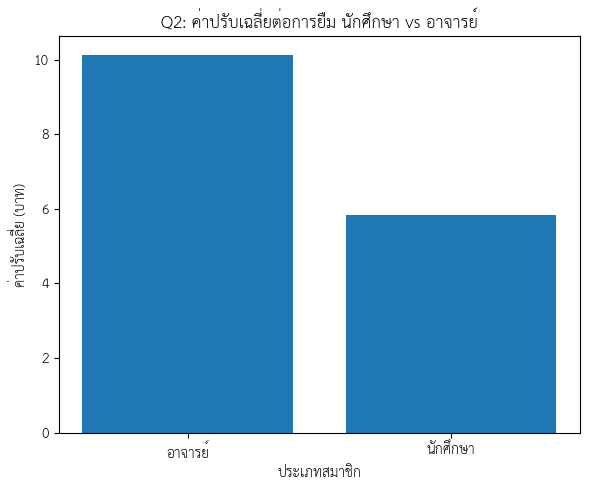

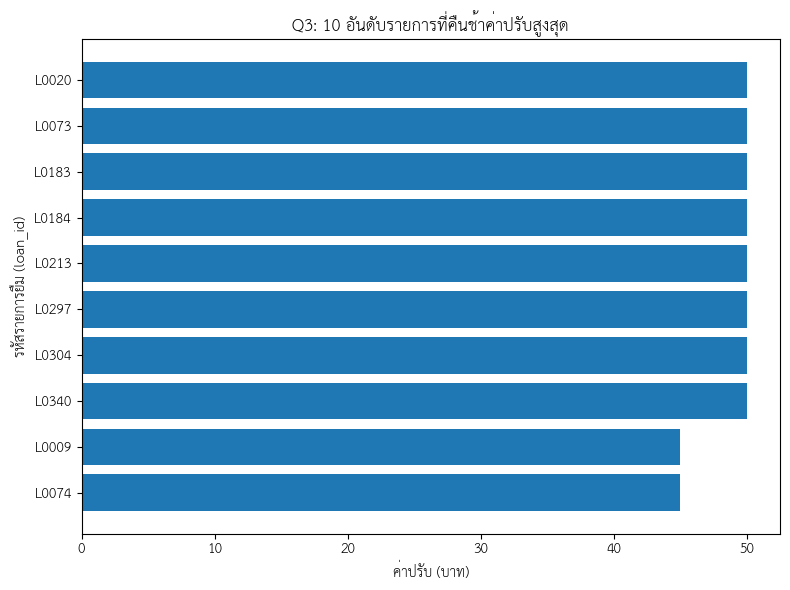

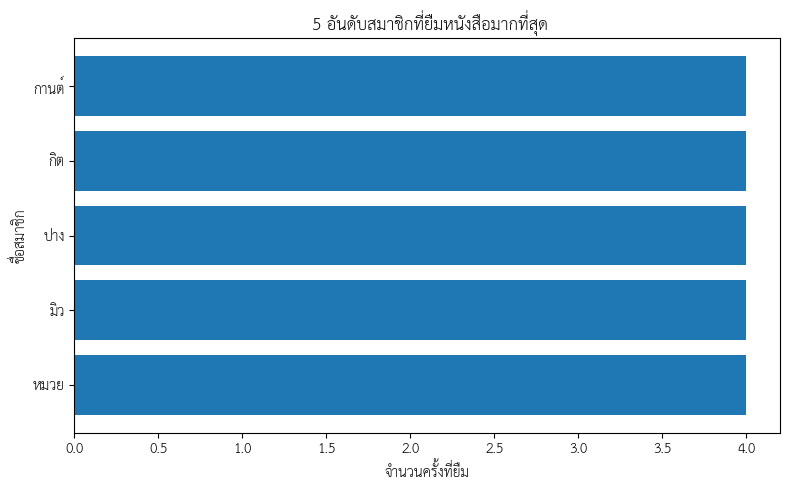

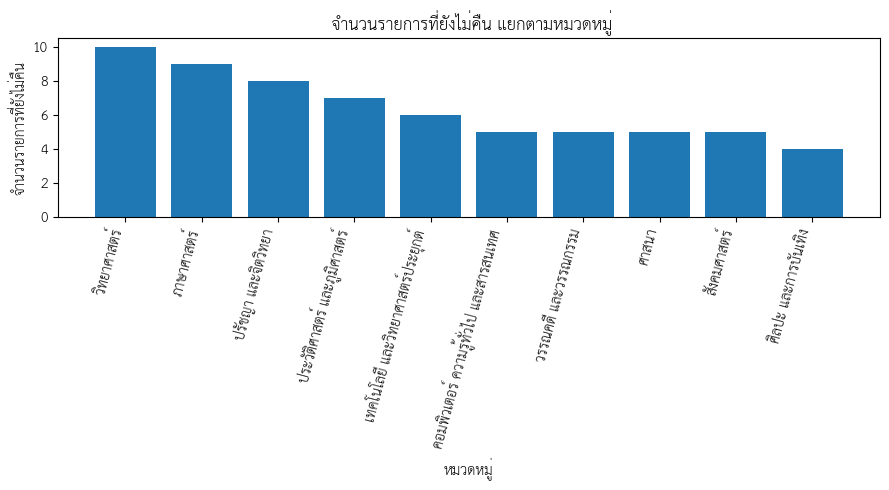

In [124]:
#สร้างกราฟตามคำถามทั้งหมด Q1-Q5
import matplotlib.pyplot as plt

#กราฟที่ 1 (Q1) — จำนวนการยืมตามหมวดหมู่
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["category_name"],
    category_summary["total_loans"]
)

plt.title("Q1: จำนวนการยืมหนังสือแยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนครั้งที่ยืม")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()


#กราฟที่ 2 (Q2) — ค่าปรับเฉลี่ยตามประเภทสมาชิก
plt.figure(figsize=(6, 5))

plt.bar(
    member_type_summary["member_type"],
    member_type_summary["avg_late_fee"]
)

plt.title("Q2: ค่าปรับเฉลี่ยต่อการยืม นักศึกษา vs อาจารย์")
plt.xlabel("ประเภทสมาชิก")
plt.ylabel("ค่าปรับเฉลี่ย (บาท)")

plt.tight_layout()
plt.show()


#กราฟที่ 3 (Q3) — 10 อันดับรายการที่ค่าปรับสูงที่สุด
top10_late = df_merged[df_merged["late_fee"] > 0].sort_values(
    ["late_fee", "loan_id"], ascending=[False, True]
).head(10)

plt.figure(figsize=(8, 6))

plt.barh(
    top10_late["loan_id"],
    top10_late["late_fee"]
)

plt.title("Q3: 10 อันดับรายการที่คืนช้าค่าปรับสูงสุด")
plt.xlabel("ค่าปรับ (บาท)")
plt.ylabel("รหัสรายการยืม (loan_id)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()




#กราฟที่ 4 (Q4) — Top 5 สมาชิกที่ยืมมากที่สุด
top_members = df_merged.groupby("name").agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values(
    ["total_borrows", "name"], ascending=[False, True]
).head(5)

plt.figure(figsize=(8, 5))

plt.barh(
    top_members["name"],
    top_members["total_borrows"]
)

plt.title(" 5 อันดับสมาชิกที่ยืมหนังสือมากที่สุด")
plt.xlabel("จำนวนครั้งที่ยืม")
plt.ylabel("ชื่อสมาชิก")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


#กราฟที่ 5 (Q5) — จำนวนรายการที่ยังไม่คืน แยกตามหมวดหมู่
not_returned_by_category = df_merged[
    df_merged["return_date"].isnull()
].groupby("category_name").agg(
    total_not_returned=("loan_id", "count")
).reset_index().sort_values(
    ["total_not_returned", "category_name"], ascending=[False, True]
)

plt.figure(figsize=(9, 5))

plt.bar(
    not_returned_by_category["category_name"],
    not_returned_by_category["total_not_returned"]
)

plt.title(" จำนวนรายการที่ยังไม่คืน แยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนรายการที่ยังไม่คืน")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()